# Проект 4. Компьютер говорит "Нет".

## Задачей данного проекта является построение модели кредитного скоринга, которая будет предсказывать вероятность невозврата кредита клиентами банка.

In [1]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

from pandas import Series

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


from sklearn.metrics import confusion_matrix, f1_score
from sklearn.metrics import auc, roc_auc_score, roc_curve

from sklearn.model_selection import GridSearchCV

%matplotlib inline

Импортируем наши данные.

In [2]:
clients = pd.read_csv('train.csv')

In [3]:
clients_test = pd.read_csv('test.csv')

In [4]:
sample_submission = pd.read_csv('sample_submission.csv')

In [5]:
sample_submission

,client_id,default
0,66799,0.441004
1,25379,0.138092
2,28825,0.373370
3,37530,0.476501
4,4264,0.304640
...,...,...
24349,96657,0.144776
24350,65908,0.878936
24351,74542,0.830871
24352,82350,0.371539


# 1. EDA

Проведем разведку признаков

In [6]:
clients.info()
clients.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73799 entries, 0 to 73798
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         73799 non-null  int64  
 1   app_date          73799 non-null  object 
 2   education         73492 non-null  object 
 3   sex               73799 non-null  object 
 4   age               73799 non-null  int64  
 5   car               73799 non-null  object 
 6   car_type          73799 non-null  object 
 7   decline_app_cnt   73799 non-null  int64  
 8   good_work         73799 non-null  int64  
 9   score_bki         73799 non-null  float64
 10  bki_request_cnt   73799 non-null  int64  
 11  region_rating     73799 non-null  int64  
 12  home_address      73799 non-null  int64  
 13  work_address      73799 non-null  int64  
 14  income            73799 non-null  int64  
 15  sna               73799 non-null  int64  
 16  first_time        73799 non-null  int64 

,client_id,app_date,education,sex,age,car,car_type,decline_app_cnt,good_work,score_bki,bki_request_cnt,region_rating,home_address,work_address,income,sna,first_time,foreign_passport,default
0,25905,01FEB2014,SCH,M,62,Y,Y,0,0,-2.008753,1,50,1,2,18000,4,1,N,0
1,63161,12MAR2014,SCH,F,59,N,N,0,0,-1.532276,3,50,2,3,19000,4,1,N,0
2,25887,01FEB2014,SCH,M,25,Y,N,2,0,-1.408142,1,80,1,2,30000,1,4,Y,0
3,16222,23JAN2014,SCH,F,53,N,N,0,0,-2.057471,2,50,2,3,10000,1,3,N,0
4,101655,18APR2014,GRD,M,48,N,N,0,1,-1.244723,1,60,2,3,30000,1,4,Y,0


In [7]:
clients_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36349 entries, 0 to 36348
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         36349 non-null  int64  
 1   app_date          36349 non-null  object 
 2   education         36178 non-null  object 
 3   sex               36349 non-null  object 
 4   age               36349 non-null  int64  
 5   car               36349 non-null  object 
 6   car_type          36349 non-null  object 
 7   decline_app_cnt   36349 non-null  int64  
 8   good_work         36349 non-null  int64  
 9   score_bki         36349 non-null  float64
 10  bki_request_cnt   36349 non-null  int64  
 11  region_rating     36349 non-null  int64  
 12  home_address      36349 non-null  int64  
 13  work_address      36349 non-null  int64  
 14  income            36349 non-null  int64  
 15  sna               36349 non-null  int64  
 16  first_time        36349 non-null  int64 

* **client_id**	- идентификатор клиента
* **education**	- уровень образования
* **sex** - пол заёмщика
* **age** - возраст заёмщика
* **car** - флаг наличия автомобиля
* **car_type** - флаг автомобиля-иномарки
* **decline_app_cnt** - количество отказанных прошлых заявок
* **good_work** - флаг наличия «хорошей» работы
* **bki_request_cnt** - количество запросов в БКИ
* **home_address**	- категоризатор домашнего адреса
* **work_address**	- категоризатор рабочего адреса
* **income** - доход заёмщика
* **foreign_passport**	- наличие загранпаспорта
* **sna** - связь заемщика с клиентами банка
* **first_time** - давность наличия информации о заемщике
* **score_bki** - скоринговый балл по данным из БКИ
* **region_rating** - рейтинг региона
* **app_date** - дата подачи заявки
* **default** - наличие дефолта

## default 

- наличие дефолта

целевая переменная

**default** - бинарный признак.

<AxesSubplot:xlabel='default', ylabel='count'>

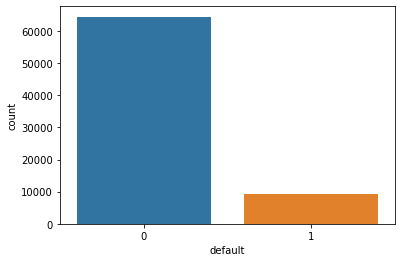

In [8]:
sns.countplot(x = 'default', data = clients)

Клиентов без дефолта намного больше. Это говорит о несбалансированности данного признака.

## education

- уровень образования

**education** - категориальный признак

In [9]:
clients['education'].value_counts()

SCH    38860
GRD    23365
UGR     9816
PGR     1257
ACD      194
Name: education, dtype: int64

<AxesSubplot:>

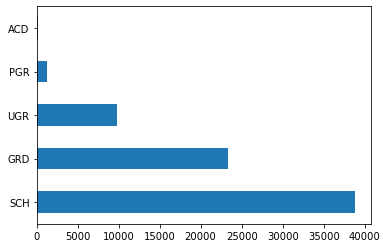

In [10]:
clients['education'].value_counts().plot.barh()

Единственный столбец с пропусками. Заполним пустые ячейки в столбце **education** значением моды.

In [11]:
clients['education'] = clients['education'].fillna('SCH')

## sex

- пол заёмщика

**sex** - бинарный признак

<AxesSubplot:xlabel='sex', ylabel='count'>

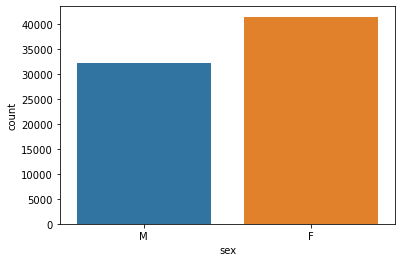

In [12]:
sns.countplot(x = 'sex', data = clients)

## age

- возраст заёмщика

age - числовой признак

<AxesSubplot:>

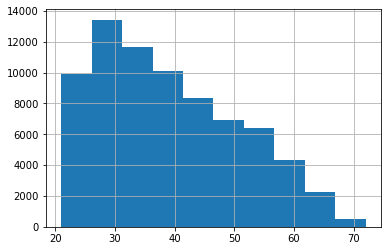

In [13]:
clients.age.hist()

Псотроим **boxplot** для оценки поведения переменной **age** относительно целевой переменной **default**

<AxesSubplot:xlabel='default', ylabel='age'>

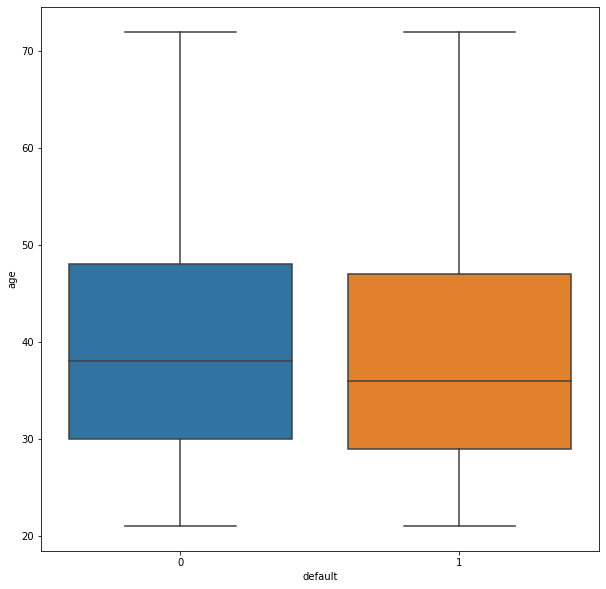

In [14]:
plt.figure(figsize = (10,10))
sns.boxplot(x = 'default', y = 'age', data = clients)

Дефолтные клиенты в среднем младше.

## car

- флаг наличия автомобиля

**car** - бинарный признак

<AxesSubplot:xlabel='car', ylabel='count'>

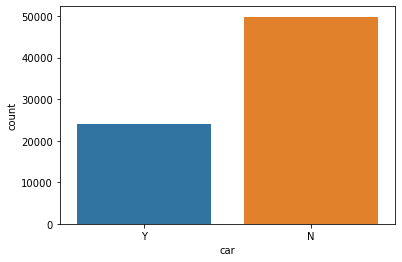

In [15]:
sns.countplot(x = 'car', data = clients)

## car_type

- флаг автомобиля-иномарки

**car_type** - бинарный признак

<AxesSubplot:xlabel='car_type', ylabel='count'>

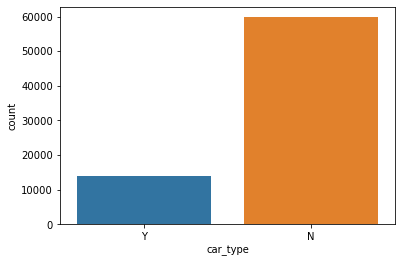

In [16]:
sns.countplot(x = 'car_type', data = clients)

## decline_app_cnt

- количество отказанных прошлых заявок

**decline_app_cnt** - числовой признак

<AxesSubplot:>

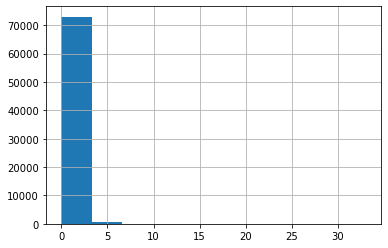

In [17]:
clients.decline_app_cnt.hist()

<AxesSubplot:xlabel='default', ylabel='decline_app_cnt'>

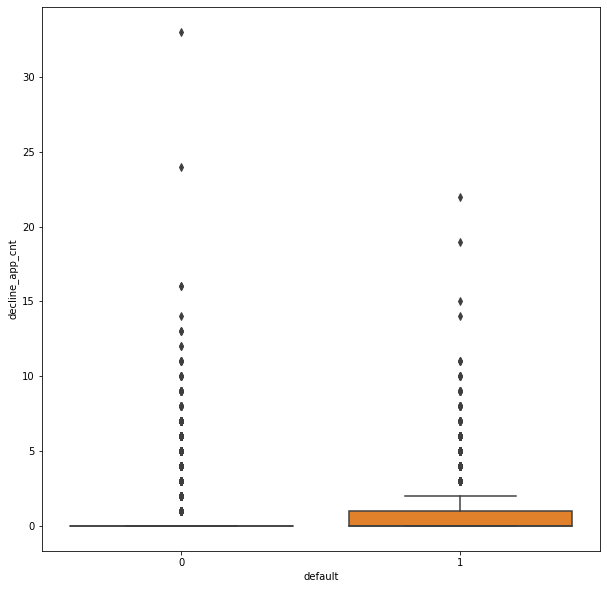

In [18]:
plt.figure(figsize = (10,10))
sns.boxplot(x = 'default', y = 'decline_app_cnt', data = clients)

Дефолтные клиенты в среднем имеют большое количество отмененных заявок.

## good_work

- флаг наличия «хорошей» работы

**good_work** - бинарный признак

<AxesSubplot:xlabel='good_work', ylabel='count'>

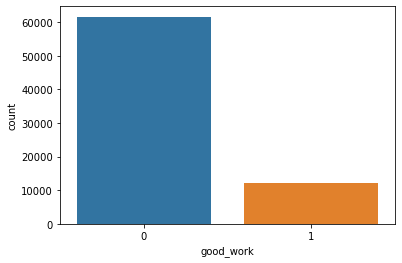

In [19]:
sns.countplot(x = 'good_work', data = clients)

## score_bki

- скоринговый балл по данным из БКИ

**score_bki** - числовой признак

<AxesSubplot:>

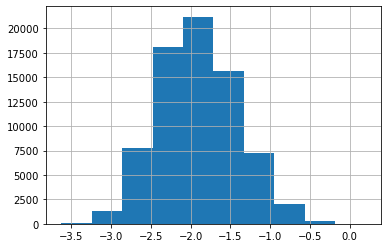

In [20]:
clients.score_bki.hist()

<AxesSubplot:xlabel='default', ylabel='score_bki'>

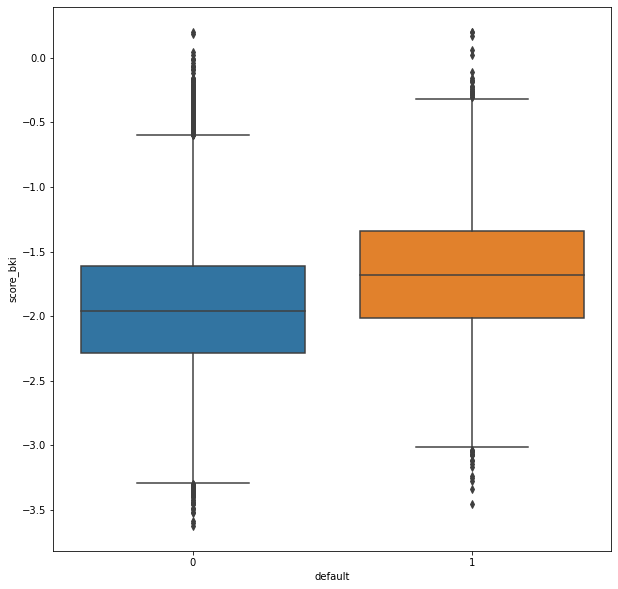

In [21]:
plt.figure(figsize = (10,10))
sns.boxplot(x = 'default', y = 'score_bki', data = clients)

Скоринговый балл по данным из БКИ в среднем больше у дефолтных клиентов.

## bki_request_cnt

- количество запросов в БКИ

**bki_request_cnt** - числовой признак

<AxesSubplot:>

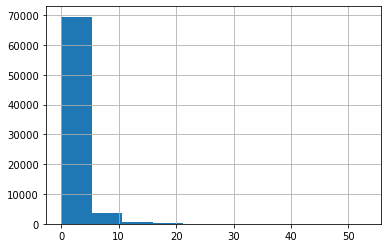

In [22]:
clients.bki_request_cnt.hist()

<AxesSubplot:xlabel='default', ylabel='bki_request_cnt'>

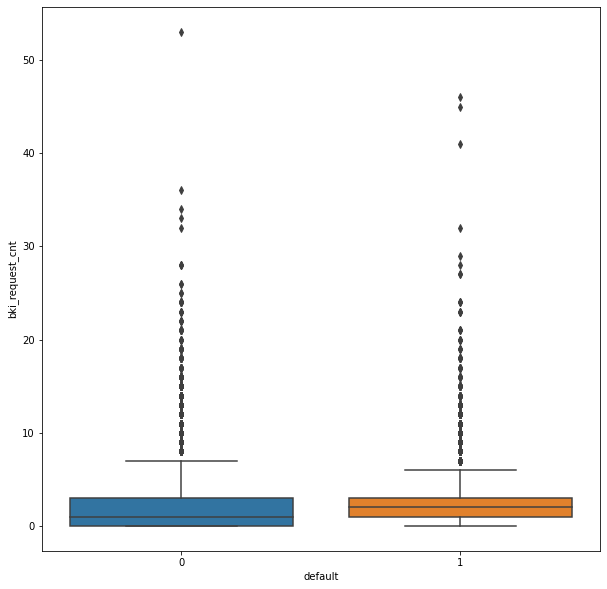

In [23]:
plt.figure(figsize = (10,10))
sns.boxplot(x = 'default', y = 'bki_request_cnt', data = clients)

Дефолтные клиенты в среднем имеют больше запросов в БКИ.

## region_rating

- рейтинг региона

**region_rating** - категориальный признак

In [24]:
clients.region_rating.value_counts()

50    27523
60    16075
40    12027
80    11469
70     6199
30      300
20      206
Name: region_rating, dtype: int64

## home_address

- категоризатор домашнего адреса

**home_address** - категориальный признак

<AxesSubplot:>

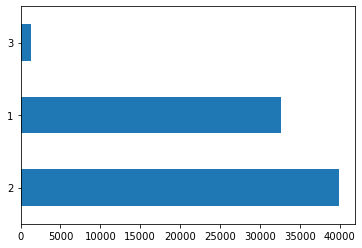

In [25]:
clients.home_address.value_counts().plot.barh()

## work_address

- категоризатор рабочего адреса

**work_address** - категориальный признак

<AxesSubplot:>

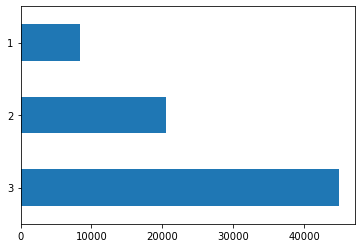

In [26]:
clients.work_address.value_counts().plot.barh()

## income

- доход заёмщика

**income** - числовой признак

<AxesSubplot:>

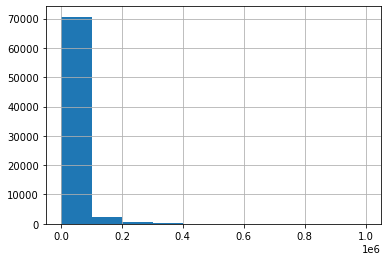

In [27]:
clients.income.hist()

<AxesSubplot:xlabel='default', ylabel='income'>

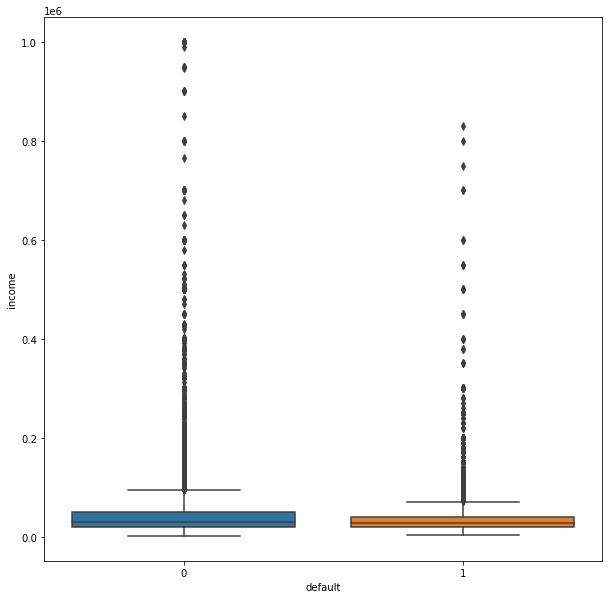

In [28]:
plt.figure(figsize = (10,10))
sns.boxplot(x = 'default', y = 'income', data = clients)

Дефолтные клиенты в среднем имеют более низкий доход.

Построим боксплоты относительно признака **region_rating**.

<AxesSubplot:xlabel='region_rating', ylabel='income'>

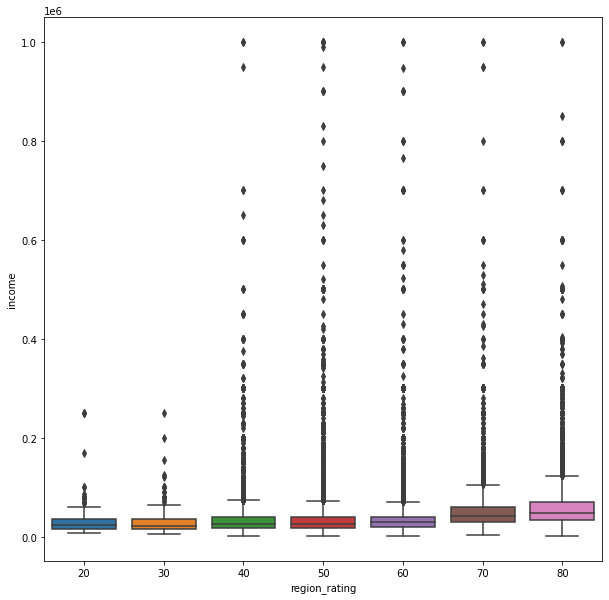

In [29]:
plt.figure(figsize = (10,10))
sns.boxplot(x = 'region_rating', y = 'income', data = clients)

Из графиков видно, что средний доход заёмщика возрастает по мере увеличения рейтинга региона. Можно сгенерировать признак, который будет отражать средний доход заёмщика в зависимости от региона.

Создадим словарь соответствий рейтинга и среднего дохода.

In [30]:
clients['region_rating'].unique()

array([50, 80, 60, 40, 70, 20, 30], dtype=int64)

In [31]:
region_income_dict = {}
for i in clients['region_rating'].unique():
    region_income_dict[i] = round(clients.income[clients['region_rating'] == i].mean(), 0)
region_income_dict 

{50: 35024.0,
 80: 61041.0,
 60: 37535.0,
 40: 33621.0,
 70: 55842.0,
 20: 31213.0,
 30: 29108.0}

Создадим новый признак **region_income**, показывающий средний доход в регионе.

In [32]:
clients['region_income'] = clients['region_rating'].replace(to_replace = region_income_dict)

**region_income** - числовой признак.

## sna

- связь заемщика с клиентами банка

**sna** - категориальный признак

<AxesSubplot:>

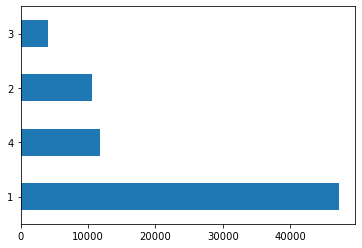

In [33]:
clients.sna.value_counts().plot.barh()

## first_time

- давность наличия информации о заемщике

**first_time** - категориальный признак

<AxesSubplot:>

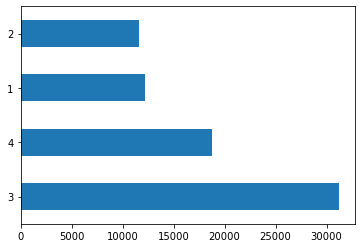

In [34]:
clients.first_time.value_counts().plot.barh()

## foreign_passport

- наличие загранпаспорта

**foreign_passport** - бинарный признак

<AxesSubplot:xlabel='foreign_passport', ylabel='count'>

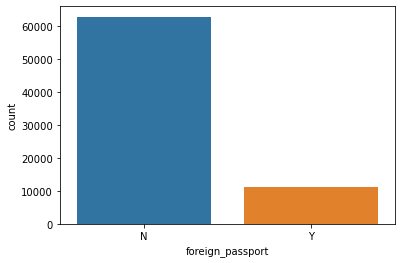

In [35]:
sns.countplot(x = 'foreign_passport', data = clients)

Полученные признаки сгруппируем в три категории по типу их обработки (категориальные, бинарные и числовые).

In [36]:
# бинарные переменные
bin_cols = ['sex', 'car', 'car_type', 'foreign_passport', 'good_work']

# категориальные переменные
cat_cols = ['education', 'home_address', 'work_address', 'region_rating', 'sna', 'first_time']

# числовые переменные
num_cols = ['age', 'decline_app_cnt', 'bki_request_cnt', 'income', 'score_bki', 'region_income']

В результате проведенного анализа стало понятно, что удаление выбросов приводит к ухудшению предсказания модели. Поэтому было решено оставить выбросы.

# 2. Числовые переменные

При анализе числовых переменных на распределениях был замечен сильный правый хвост. Чтобы компенсировать его сделаем логарифмирование этих переменных. Так как логарифмов отрицательных чисел не существует, вычислим минимальное отрицательное число и затем компенсируем все отрицательные числа наших признаков.

In [37]:
clients[num_cols].min()

age                   21.000000
decline_app_cnt        0.000000
bki_request_cnt        0.000000
income              1000.000000
score_bki             -3.624586
region_income      29108.000000
dtype: float64

Минимальное число равно - 3.62. Значит для компенсации возьмем целое число 4.

In [38]:
for i in num_cols:
    clients[i] = np.log(clients[i] + 4)

Вновь посмотрим на все распределения.

C:\Users\User\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


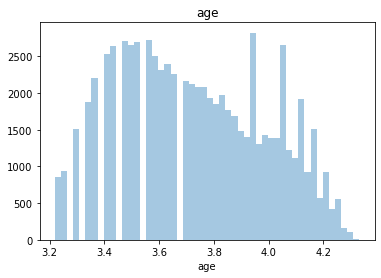

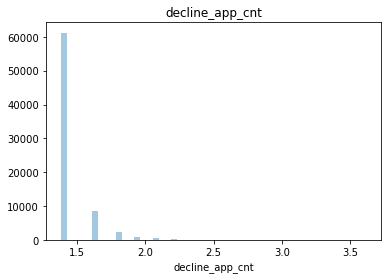

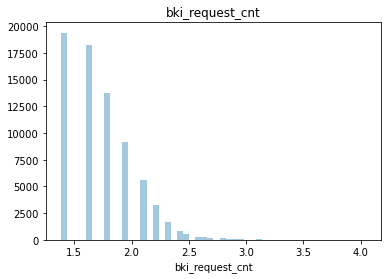

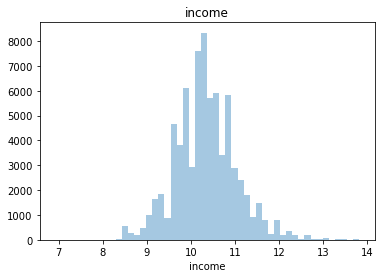

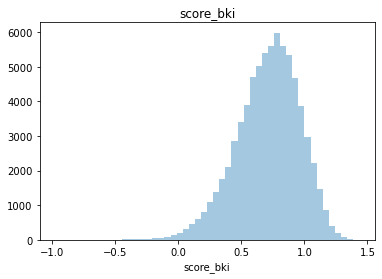

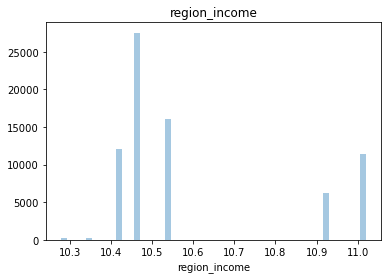

In [39]:
for i in num_cols:
    plt.figure()
    sns.distplot(clients[i], kde = False, rug=False)
    plt.title(i)
    plt.show()

В результате некоторые переменные стали менее смещенными.

Оценим корреляцию числовых переменных и целевой переменной.


<AxesSubplot:>

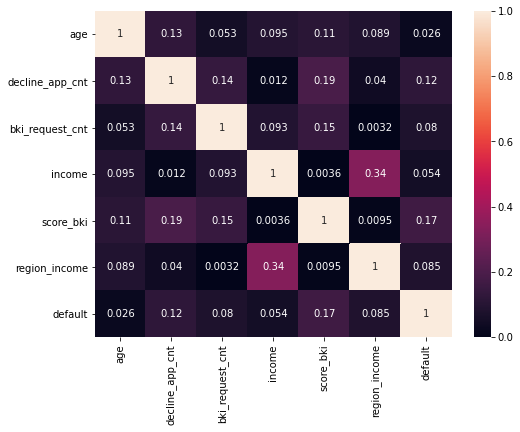

In [40]:
plt.figure(figsize = (8,6))
sns.heatmap(clients[num_cols + ['default']].corr().abs(), vmin=0, vmax=1, annot = True)

Числовые признаки имеют низкую корреляцию друг с другом и с целевой переменной. Поэтому все числовые признаки следует оставить для обучения модели.

Оценим значимость числовых переменных.

<AxesSubplot:>

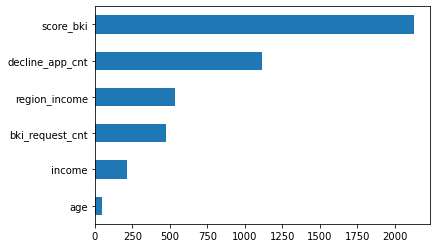

In [41]:
imp_num = Series(f_classif(clients[num_cols], clients['default'])[0], index = num_cols)
imp_num.sort_values(inplace = True)
imp_num.plot(kind = 'barh')

Отсюда видно, что наиболее важный признак - это скоринговый балл по данным из БКИ, а наименее - возраст заемщика.

# 3. Категориальные переменные

Преобразуем категориальные данные в числа.

Применим LabelEncoder ко всему набору бинарных переменных.

In [42]:
label_encoder = LabelEncoder()

for column in bin_cols:
    clients[column] = label_encoder.fit_transform(clients[column])
    
# убедимся в преобразовании    
clients.head()

,client_id,app_date,education,sex,age,car,car_type,decline_app_cnt,good_work,score_bki,bki_request_cnt,region_rating,home_address,work_address,income,sna,first_time,foreign_passport,default,region_income
0,25905,01FEB2014,SCH,1,4.189655,1,1,1.386294,0,0.688761,1.609438,50,1,2,9.798349,4,1,0,0,10.463903
1,63161,12MAR2014,SCH,0,4.143135,0,0,1.386294,0,0.903296,1.945910,50,2,3,9.852405,4,1,0,0,10.463903
2,25887,01FEB2014,SCH,1,3.367296,1,0,1.791759,0,0.952375,1.609438,80,1,2,10.309086,1,4,1,0,11.019367
3,16222,23JAN2014,SCH,0,4.043051,0,0,1.386294,0,0.663991,1.791759,50,2,3,9.210740,1,3,0,0,10.463903
4,101655,18APR2014,GRD,1,3.951244,0,0,1.386294,1,1.013518,1.609438,60,2,3,10.309086,1,4,1,0,10.533136


Преобразуем признак **education** в целочисленный формат.

In [43]:
clients.education.value_counts()

SCH    39167
GRD    23365
UGR     9816
PGR     1257
ACD      194
Name: education, dtype: int64

In [44]:
education_dict = {'SCH':1, 'GRD':2, 'UGR':3, 'PGR':4, 'ACD':5}
clients['education'] = clients['education'].replace(to_replace = education_dict)

Оценим значимость категориальных и бинарных переменных.

<AxesSubplot:>

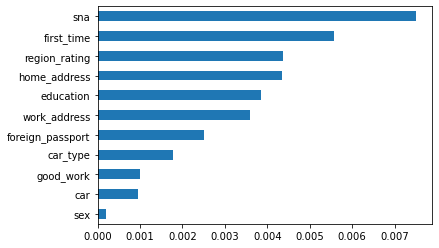

In [45]:
imp_cat = Series(mutual_info_classif(clients[bin_cols + cat_cols], clients['default'],
                                     discrete_features =True), index = bin_cols + cat_cols)
imp_cat.sort_values(inplace = True)
imp_cat.plot(kind = 'barh')

Наиболее важна связь заемщиков с клиентами банка, наименее - пол заемщика.

# 4. Подготовка данных к машинному обучению

Осуществим dummy-кодирование категориальных переменных.

In [46]:
X_cat = OneHotEncoder(sparse = False).fit_transform(clients[cat_cols].values)

Стандартизируем числовые переменные.

In [47]:
# Стандартизация числовых переменных

X_num = StandardScaler().fit_transform(clients[num_cols].values)

Объединим стандартизованные числовые, бинарные и закодированные категориальные переменные в одно признаковое пространство, разделив при этом признаки и целевую переменную.

In [67]:
# Объединяем

X = np.hstack([X_num, clients[bin_cols].values, X_cat])
y = clients['default'].values

Разделим данные для обучения следующим образом:

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 5. Обучение модели

Обучим модель.

C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


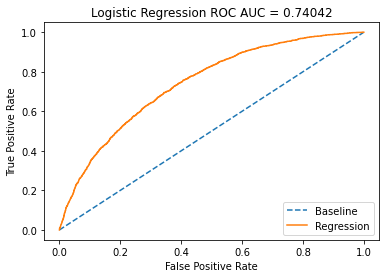

In [50]:
model = LogisticRegression()
model.fit(X_train, y_train)

probs = model.predict_proba(X_test)
probs = probs[:,1]


fpr, tpr, threshold = roc_curve(y_test, probs)
roc_auc = roc_auc_score(y_test, probs)

plt.figure()
plt.plot([0, 1], label='Baseline', linestyle='--')
plt.plot(fpr, tpr, label = 'Regression')
plt.title('Logistic Regression ROC AUC = %0.5f' % roc_auc)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc = 'lower right')
plt.show()

In [51]:
y_pred = model.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(tp, fp) 
print(fn, tn)

34 50
1793 12883


In [52]:
f1 = f1_score(y_test, y_pred)
print('f1 = {}'.format(f1))

f1 = 0.035583464154892726


После обучения модели были получены следующие метрики: confusion matrix = [[34, 50], [1793, 12883]], f1 = 0.036 и ROC AUC = 0.74042. На основании низких значений tp и f1 можно сделать вывод, что модель плохо обучилась и обладает слабой предсказательной способностью. Это связано с несбалансированностью целевой переменной.

# 6. Регуляризация

Подберем гиперпараметры для улучшения модели. Также для улучшения сбалансированности передадим в нашу модель параметр class_weight = 'balanced'.

In [53]:
# Добавим типы регуляризации
penalty = ['l1', 'l2']

# Зададим ограничения для параметра регуляризации
C = np.logspace(0, 4, 10)

# Создадим гиперпараметры
hyperparameters = dict(C=C, penalty=penalty)

model = LogisticRegression(class_weight = 'balanced')
model.fit(X_train, y_train)

# Создаем сетку поиска с использованием 5-кратной перекрестной проверки
clf = GridSearchCV(model, hyperparameters, cv=5, verbose=0)

best_model = clf.fit(X_train, y_train)

# View best hyperparameters
print('Лучшее Penalty:', best_model.best_estimator_.get_params()['penalty'])
print('Лучшее C:', best_model.best_estimator_.get_params()['C'])

C:\Users\User\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:548: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\User\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 531, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1304, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 442, in _check_solver
    raise ValueError("Solver %s supports only 'l2' or 'none' penalties, "
ValueError: Solver lbfgs supports only 'l2' or 'none' penalties, got l1 penalty.

  warnings.warn("Estimator fit failed. The score on this train-test"
C:\Users\User\anaconda3\lib\site-packages\sklearn\model_selection\_valida

C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\User\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:548: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\User\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 531, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_mo

Лучшее Penalty: l2
Лучшее C: 59.94842503189409


В результате мы получили модель с оптимальными гиперпараметрами Penalty: l2 и C: 59.95. Сделаем предсказание на основе полученной best_model.

In [54]:
best_model.fit(X_train, y_train)

C:\Users\User\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:548: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\User\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 531, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 1304, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py", line 442, in _check_solver
    raise ValueError("Solver %s supports only 'l2' or 'none' penalties, "
ValueError: Solver lbfgs supports only 'l2' or 'none' penalties, got l1 penalty.

  warnings.warn("Estimator fit failed. The score on this train-test"
C:\Users\User\anaconda3\lib\site-packages\sklearn\model_selection\_valida

C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\User\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:548: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\User\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 531, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\User\anaconda3\lib\site-packages\sklearn\linear_mo

GridSearchCV(cv=5, estimator=LogisticRegression(class_weight='balanced'),
             param_grid={'C': array([1.00000000e+00, 2.78255940e+00, 7.74263683e+00, 2.15443469e+01,
       5.99484250e+01, 1.66810054e+02, 4.64158883e+02, 1.29154967e+03,
       3.59381366e+03, 1.00000000e+04]),
                         'penalty': ['l1', 'l2']})

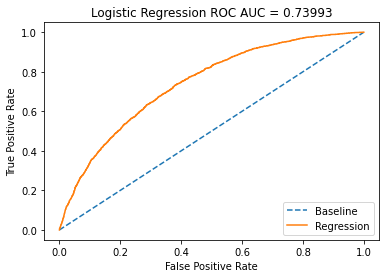

In [55]:
probs = best_model.predict_proba(X_test)
probs = probs[:,1]


fpr, tpr, threshold = roc_curve(y_test, probs)
roc_auc = roc_auc_score(y_test, probs)

plt.figure()
plt.plot([0, 1], label='Baseline', linestyle='--')
plt.plot(fpr, tpr, label = 'Regression')
plt.title('Logistic Regression ROC AUC = %0.5f' % roc_auc)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc = 'lower right')
plt.show()

In [56]:
y_pred = best_model.predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(tp, fp) 
print(fn, tn)

1258 4427
569 8506


In [57]:
f1 = f1_score(y_test, y_pred)
print('f1 = {}'.format(f1))

f1 = 0.33493077742279015


Показатели confusion matrix = [[1258, 4428], [569, 8505]] и f1 = 0.33 стали значительно лучше, следовательно предсказательная способность модели ощутимо возросла и модель стала намного ближе к рабочей  версии. А вот ROC AUC = 0.73994 незначительно уменьшился, что не сказалось на прогонозируемости модели.

#  7. Submission.

Submission будем делать на тестовой выборке clients_test. Предварительно ее также как и тренировочную нужно подвергнуть предобработке.

Завернем всю предобработку в функцию.

In [58]:
def data_preparation(df):
    
    # заполнение пропусков
    df['education'] = df['education'].fillna('SCH')
    
    # генерация признака region_income
    region_income_dict = {}
    for i in clients['region_rating'].unique():
        region_income_dict[i] = round(clients.income[clients['region_rating'] == i].mean(), 0)
    df['region_income'] = df['region_rating'].replace(to_replace = region_income_dict)
    
    # бинарные переменные
    bin_cols = ['sex', 'car', 'car_type', 'foreign_passport', 'good_work']
    
    # категориальные переменные
    cat_cols = ['education', 'home_address', 'work_address', 'region_rating', 'sna', 'first_time']
    
    # числовые переменные
    num_cols = ['age', 'decline_app_cnt', 'bki_request_cnt', 'income', 'score_bki', 'region_income']
    
    # логарифмирование
    for i in num_cols:
        clients[i] = np.log(clients[i] + 4)
    
    # преобразование бинарных признаков
    label_encoder = LabelEncoder()
    
    for column in bin_cols:
        df[column] = label_encoder.fit_transform(df[column])
    
    # преобразование категориальных значений в целочисленные
    education_dict = {'SCH':1, 'GRD':2, 'UGR':3, 'PGR':4, 'ACD':5}
    df['education'] = df['education'].replace(to_replace = education_dict)
    
    # dummy-кодирование категориальных переменных
    X_cat = OneHotEncoder(sparse = False).fit_transform(df[cat_cols].values)
    
    # стандартизация числовых переменных
    X_num = StandardScaler().fit_transform(df[num_cols].values)
    
    # объединение всех признаков
    X = np.hstack([X_num, df[bin_cols], X_cat])
    
    return X

Получим значения признаков для предсказания.

In [59]:
X_test = data_preparation(clients_test)

Предскажем значения целевой переменной.

In [60]:
probs = best_model.predict_proba(X_test)
probs = probs[:,1]

Создадим непосредственно submission с данными id клиентов.

In [61]:
submission = pd.DataFrame(clients_test['client_id'])

И запишем туда предсказания.

In [62]:
submission = pd.concat([submission, pd.DataFrame(probs, columns = ['default'])], axis = 1)

In [63]:
submission

,client_id,default
0,74835,0.210020
1,17527,0.794112
2,75683,0.324456
3,26883,0.362496
4,28862,0.136603
...,...,...
36344,83775,0.758774
36345,106254,0.146353
36346,81852,0.796826
36347,1971,0.544361


Создадим файл представления.

In [64]:
submission.to_csv('submission.csv', index=False)